#1 Simulating 1-D RV's session. 

#1.1 Binomial RV, convergence to the mean.

Core idea: Each new data point matters less, and randomness cancels itself out.

In [1]:
import numpy as np

In [2]:
p = 0.3
N = 10
samples = np.random.binomial(1,p,size=N)
print(samples)

[0 1 0 1 0 1 1 0 0 0]


In [3]:
empirical_mean = np.mean(samples)
print(empirical_mean)

0.4


In [4]:
N = 1000

In [7]:
samples = np.random.binomial(1,p,size=N)
empirical_mean = np.mean(samples)
print("Empirical mean: ", empirical_mean)
print("Theoretical mean: ", p)

Empirical mean:  0.308
Theoretical mean:  0.3


In [8]:
import matplotlib.pyplot as plt

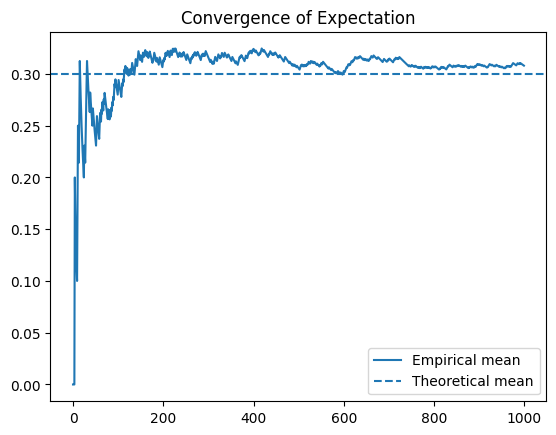

In [10]:
running_mean = np.cumsum(samples) / np.arange(1, N+1)
plt.plot(running_mean, label = "Empirical mean")
plt.axhline(y=p, linestyle = '--', label = "Theoretical mean")
plt.legend()
plt.title("Convergence of Expectation")
plt.show()

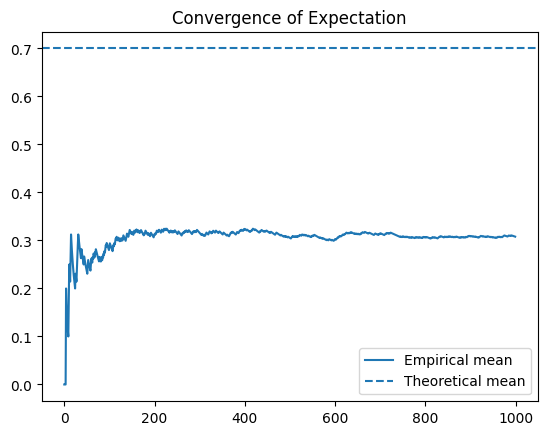

In [11]:
p=0.7
running_mean = np.cumsum(samples) / np.arange(1, N+1)
plt.plot(running_mean, label = "Empirical mean")
plt.axhline(y=p, linestyle = '--', label = "Theoretical mean")
plt.legend()
plt.title("Convergence of Expectation")
plt.show()

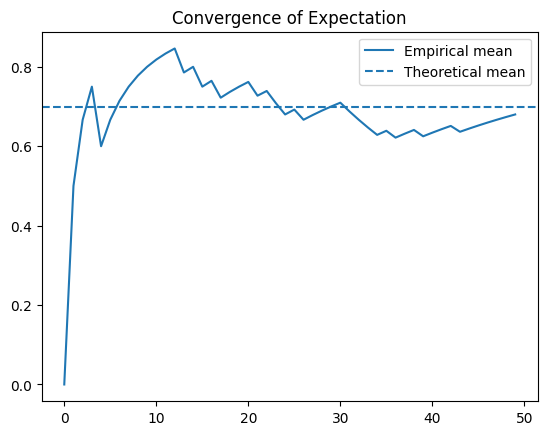

In [13]:
p=0.7 
N=50
samples = np.random.binomial(1,p,size=N)
running_mean = np.cumsum(samples) / np.arange(1, N+1)
plt.plot(running_mean, label = "Empirical mean")
plt.axhline(y=p, linestyle = '--', label = "Theoretical mean")
plt.legend()
plt.title("Convergence of Expectation")
plt.show()

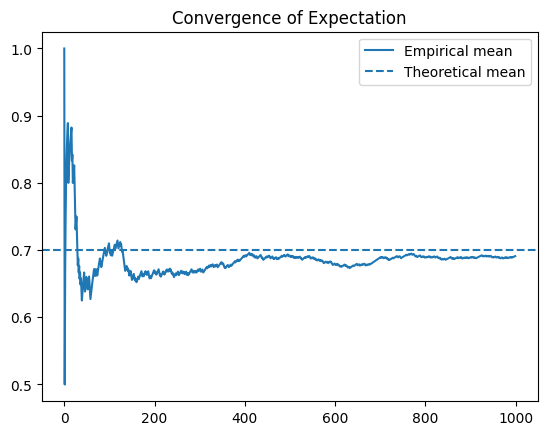

In [14]:
p=0.7 
N=1000
samples = np.random.binomial(1,p,size=N)
running_mean = np.cumsum(samples) / np.arange(1, N+1)
plt.plot(running_mean, label = "Empirical mean")
plt.axhline(y=p, linestyle = '--', label = "Theoretical mean")
plt.legend()
plt.title("Convergence of Expectation")
plt.show()

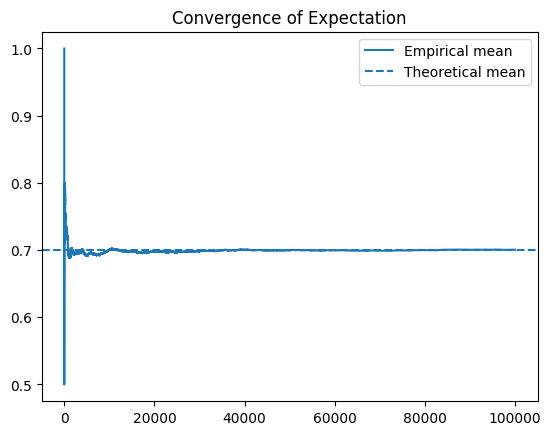

In [15]:
p=0.7 
N=100000
samples = np.random.binomial(1,p,size=N)
running_mean = np.cumsum(samples) / np.arange(1, N+1)
plt.plot(running_mean, label = "Empirical mean")
plt.axhline(y=p, linestyle = '--', label = "Theoretical mean")
plt.legend()
plt.title("Convergence of Expectation")
plt.show()

In [16]:
for n in [10, 100, 1000, 10000]:
    samples = np.random.binomial(1, p, size=n)
    print(n, np.mean(samples))

10 0.7
100 0.75
1000 0.712
10000 0.7019


#1.2 Exponential RV, generating from Uniform

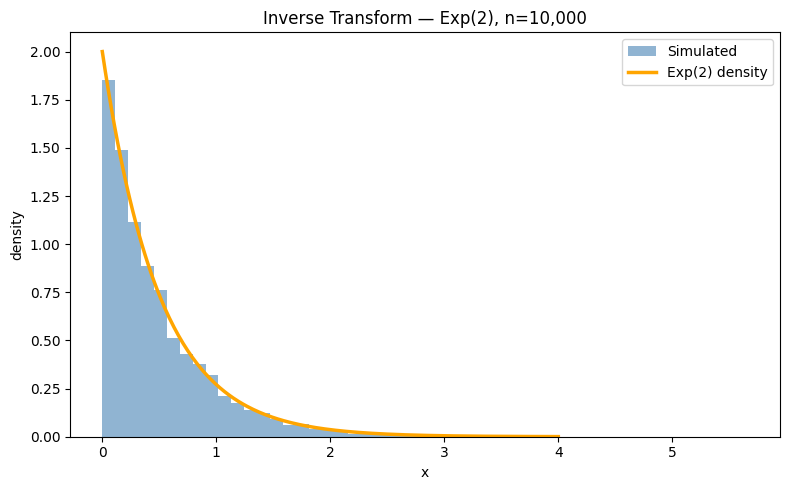

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_exponential(n, lam):
    u = np.random.uniform(0, 1, n)
    return -1/lam * np.log(u)

# Simulate
lam = 2
samples = simulate_exponential(10000, lam)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram — density=True normalizes so area=1, matching the density
ax.hist(samples, bins=50, density=True, alpha=0.6, 
        color='steelblue', label='Simulated')

# Theoretical density f(x) = lambda * exp(-lambda * x)
x = np.linspace(0, 4, 300)
ax.plot(x, lam * np.exp(-lam * x), 
        color='orange', lw=2.5, label=f'Exp({lam}) density')

ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_title(f'Inverse Transform — Exp({lam}), n=10,000')
ax.legend()
plt.tight_layout()
plt.show()

#1.2 Gamma RV, as sum of Exponential, generating from Uniform 

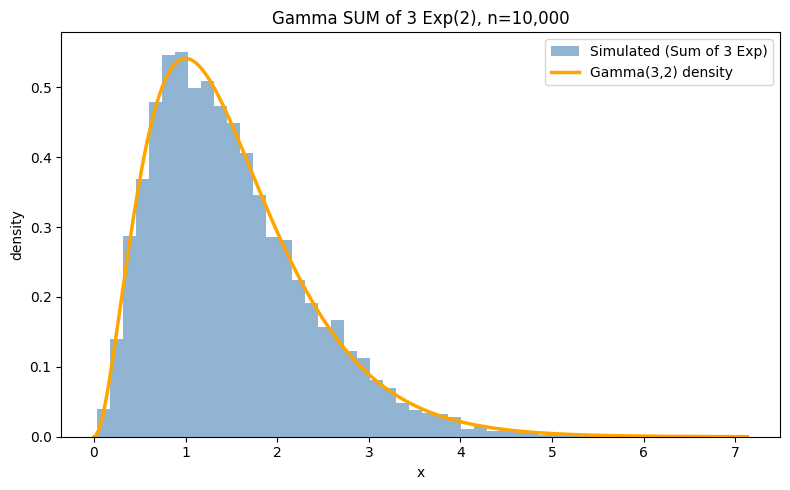

In [7]:
import numpy as np
import matplotlib.pyplot as plt
###import math
from scipy.special import gamma


def simulate_exponential(n, lam):
    u = np.random.uniform(0, 1, n)
    return -1/lam * np.log(u)

# Simulate
lam = 2
k = 3
n_samples = 10000

# Gamma as sum of Exponential RVs:
simulated_gamma = sum(simulate_exponential(n_samples, lam) 
                      for i in range(k)) #works for any k

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Simulated pdf-Histogram — density=True normalizes so area=1, matching the density
ax.hist(simulated_gamma, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Simulated (Sum of {k} Exp)')

# Generate 300 evenly spaced x-values from 0 to the maximum value in our 'gamma' array
x = np.linspace(0, max(simulated_gamma), 300)

# Theoretical Gamma PDF formula: (lam^k * x^(k-1) * e^(-lam * x)) / factorial(k-1)
numerator = (lam**k) * (x**(k-1)) * np.exp(-lam*x)
denominator = gamma(k)   # gamma(k) = (k-1)! for integer k
theoretical_gamma = numerator / denominator

# Theoretical pdf-Curve
ax.plot(x, theoretical_gamma, color='orange', 
        lw=2.5, label=f'Gamma(3,{lam}) density')


ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_title(f'Gamma SUM of {k} Exp({lam}), n=10,000')
ax.legend()
plt.tight_layout()
plt.show()

#1.3 Box-Mueller for Normal RVs

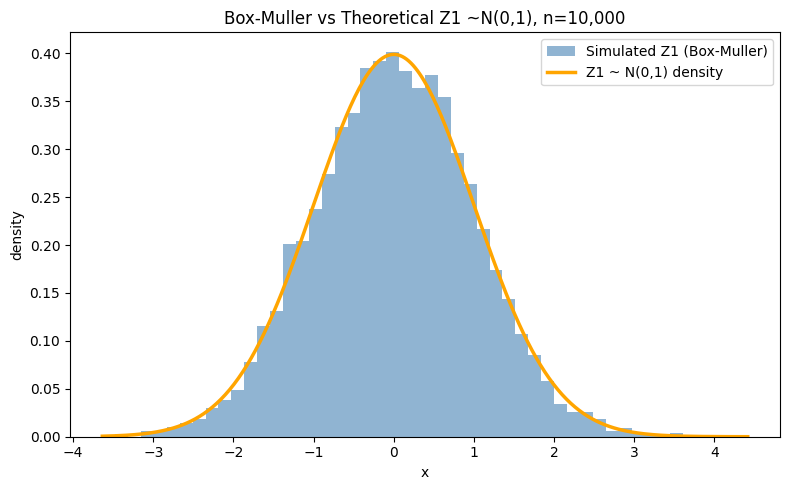

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_normal_boxmuller(n):
    u1 = np.random.uniform(0, 1, n)
    u2 = np.random.uniform(0, 1, n)
    z1 = np.sqrt((-2) * np.log(u1)) * np.cos(2 * np.pi * u2)
    z2 = np.sqrt((-2) * np.log(u1)) * np.sin(2 * np.pi * u2)
    return z1, z2

# Simulate for n_samples
n_samples = 10000
z1, z2 = simulate_normal_boxmuller(n_samples)

# Simulated Z1 plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(z1, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Simulated Z1 (Box-Muller)')

# Generate 300 evenly spaced x-values from simulated z1 for theoretical ~N(0,1) 
x = np.linspace(min(z1), max(z1), 300)

# Theoretical Z1 pdf
theoretical_z1 = (np.exp(-(x**2) / 2))/ (np.sqrt(2 * np.pi))

ax.plot(x, theoretical_z1, color='orange', 
        lw=2.5, label=f'Z1 ~ N(0,1) density')


ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_title(f'Box-Muller vs Theoretical Z1 ~N(0,1), n=10,000')
ax.legend()
plt.tight_layout()
plt.show()

Plotting Z1 vs Z2 to verify independence

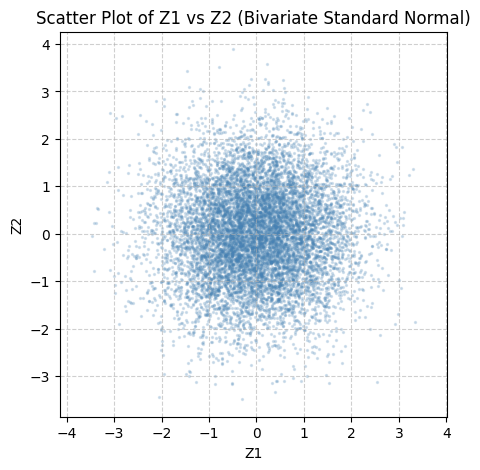

In [19]:
import matplotlib.pyplot as plt

# Set the figure size to be perfectly square
plt.figure(figsize=(5, 5))

# Create the scatter plot
# s=2 controls the dot size, alpha=0.2 makes them semi-transparent
plt.scatter(z1, z2, color='steelblue', s=2, alpha=0.2)

# Force the X and Y axes to have the exact same scale
# This is crucial! Without it, a perfect circle might look like an oval.
plt.axis('equal')

# Add context and labels
plt.title('Scatter Plot of Z1 vs Z2 (Bivariate Standard Normal)')
plt.xlabel('Z1')
plt.ylabel('Z2')

# Add a light grid for reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

(Z1,Z2) statistics

In [29]:
print(f"Z1 mean: {np.mean(z1)}")
print(f"Z1 variance: {np.var(z1)}")
print(f"Z2 variance: {np.var(z2)}")
print(f"Z1, Z2 covariance: {np.cov(z1, z2)[0, 1]}")

Z1 mean: -0.014968483666520652
Z1 variance: 0.9971985169486034
Z2 variance: 1.004929345192276
Z1, Z2 covariance: 0.015056563167516402


For Normal RV with mu=2 and sigma=3

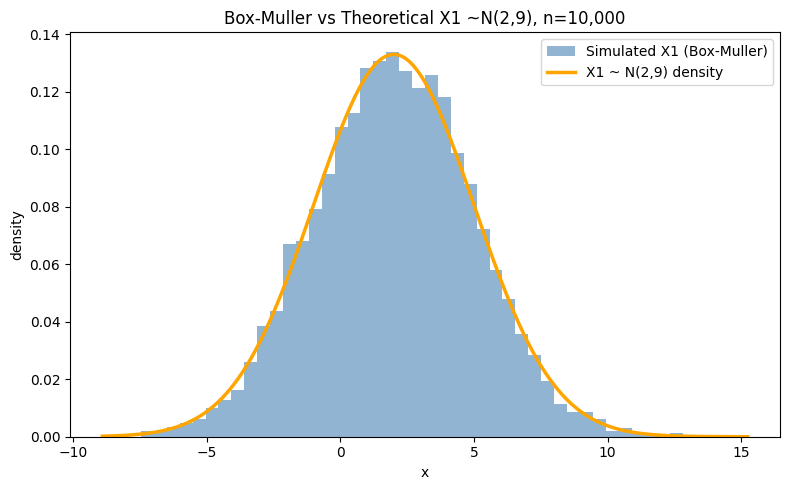

In [10]:
import numpy as np
import matplotlib.pyplot as plt

mu = 2
sigma = 3
x1 = mu + (sigma * z1)

# Simulated X1 plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(x1, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Simulated X1 (Box-Muller)')

# Generate 300 evenly spaced x-values from simulated z1 for theoretical ~N(0,1) 
x = np.linspace(min(x1), max(x1), 300)

# Theoretical X1 pdf
numerator = np.exp((-(x-mu)**2) / (2*(sigma**2)))
denominator = sigma * (np.sqrt(2 * np.pi))
theoretical_x1 = numerator / denominator

ax.plot(x, theoretical_x1, color='orange', 
        lw=2.5, label=f'X1 ~ N(2,9) density')

ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_title(f'Box-Muller vs Theoretical X1 ~N(2,9), n=10,000')
ax.legend()
plt.tight_layout()
plt.show()

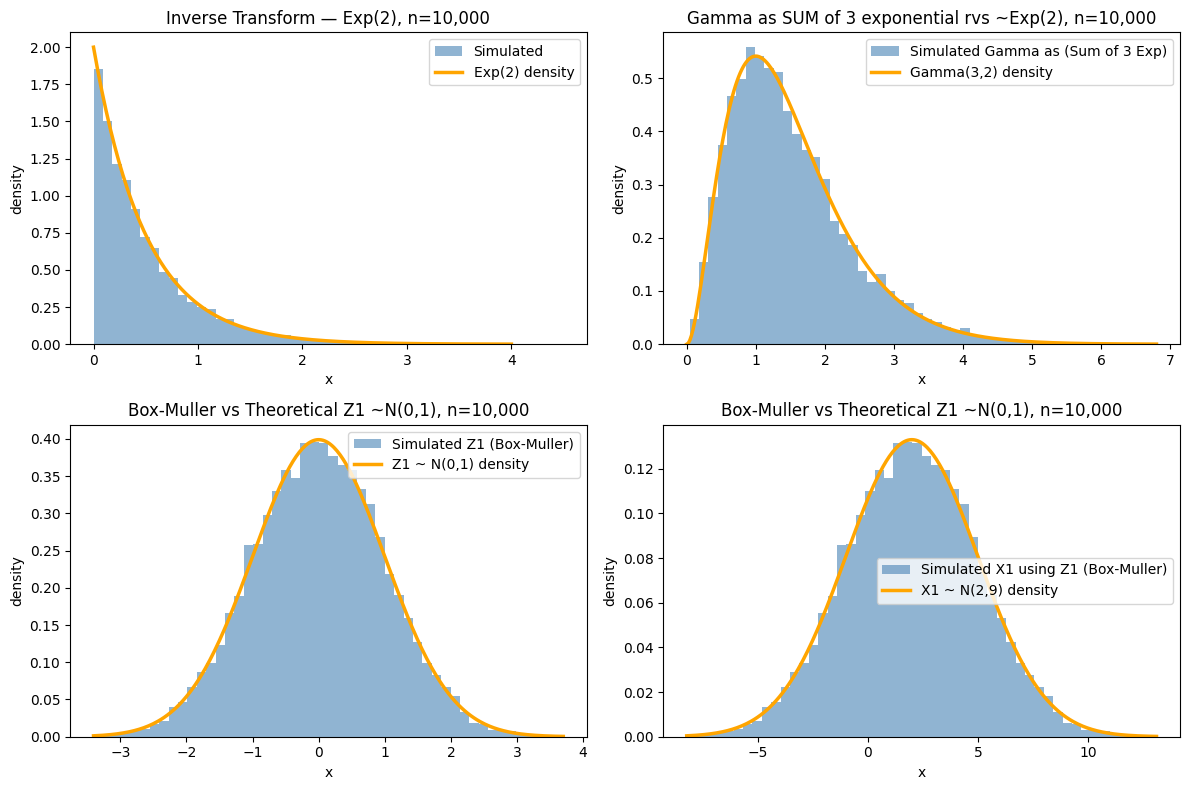

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Universal n - number of samples for all RVs:
n = 10000

# Universal preset for 4 - Plots:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#################### EXPONENTIAL #############################
# Exponential simulated function:
def simulate_exponential(n, lam):
    u = np.random.uniform(0, 1, n)
    return -1/lam * np.log(u)

# Simulate exponential
lam = 2
simulated_exp = simulate_exponential(n, lam)

# Exponential theoretical:
exp_x = np.linspace(0, 4, 300)
theoretical_exp = lam * np.exp(-lam * exp_x)


# Exponential Simulated Histogram — density=True normalizes so area=1, matching the density
axes[0, 0].hist(simulated_exp, bins=50, density=True, alpha=0.6, 
        color='steelblue', label='Simulated')


# Exponential Theoretical pdf-Curve
axes[0, 0].plot(exp_x, theoretical_exp, 
        color='orange', lw=2.5, label=f'Exp({lam}) density')

axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('density')
axes[0, 0].set_title(f'Inverse Transform — Exp({lam}), n=10,000')
axes[0, 0].legend()
#plt.tight_layout()
#plt.show()

#################### GAMMA  #############################
from scipy.special import gamma

# Gamma Simulation parameters:
k = 3

# Gamma simulated as sum of Exponential RVs:
simulated_gamma = sum(simulate_exponential(n, lam) 
                      for i in range(k)) #works for any k


# Gamma Theoretical PDF formula: (lam^k * x^(k-1) * e^(-lam * x)) / factorial(k-1):
gamma_x = np.linspace(0, max(simulated_gamma), 300) # 300 evenly spaced x-values from 0 to the maximum value in our 'gamma' array
numerator = (lam**k) * (gamma_x**(k-1)) * np.exp(-lam*gamma_x)
denominator = gamma(k)   # gamma(k) = (k-1)! for integer k
theoretical_gamma = numerator / denominator


# Gamma Simulated Histogram — density=True normalizes so area=1, matching the density
axes[0, 1].hist(simulated_gamma, bins=50, density=True, alpha=0.6, 
        color='steelblue', label=f'Simulated Gamma as (Sum of {k} Exp)')

# Gamma Theoretical pdf-Curve:
axes[0, 1].plot(gamma_x, theoretical_gamma, color='orange', 
        lw=2.5, label=f'Gamma({k},{lam}) density')


axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('density')
axes[0, 1].set_title(f'Gamma as SUM of {k} exponential rvs ~Exp({lam}), n=10,000')
axes[0, 1].legend()

#################### Z1,Z2 ~ N(0,1)  #############################

# Standard normal simulated using Box-Mullerfunction:
def simulate_normal_boxmuller(n):
    u1 = np.random.uniform(0, 1, n)
    u2 = np.random.uniform(0, 1, n)
    z1 = np.sqrt((-2) * np.log(u1)) * np.cos(2 * np.pi * u2)
    z2 = np.sqrt((-2) * np.log(u1)) * np.sin(2 * np.pi * u2)
    return z1, z2

# Z1 STD Normal Simulated 
z1, z2 = simulate_normal_boxmuller(n)

# Z1 Theoretical pdf
normal_x = np.linspace(min(z1), max(z1), 300)  # Generate 300 evenly spaced x-values from simulated z1 for theoretical ~N(0,1) 
theoretical_z1 = (np.exp(-(normal_x**2) / 2))/ (np.sqrt(2 * np.pi))

# Z1 Simulated Histogram — density=True normalizes so area=1, matching the density
axes[1, 0].hist(z1, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Simulated Z1 (Box-Muller)')

# Z1 Theoretical pdf-Curve
axes[1, 0].plot(normal_x, theoretical_z1, color='orange', 
        lw=2.5, label=f'Z1 ~ N(0,1) density')


axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('density')
axes[1, 0].set_title(f'Box-Muller vs Theoretical Z1 ~N(0,1), n=10,000')
axes[1, 0].legend()

#################### X ~ N(2,9)  #############################

# Normal Simulation parameters:
mu = 2
sigma = 3

# Normal simulation:
x1 = mu + (sigma * z1)

# X1 Theoretical pdf
normal_x1 = np.linspace(min(x1), max(x1), 300) # Generate 300 evenly spaced x-values from simulated z1 for theoretical ~N(0,1) 

numerator = np.exp((-(normal_x1-mu)**2) / (2*(sigma**2)))
denominator = sigma * (np.sqrt(2 * np.pi))
theoretical_x1 = numerator / denominator

# Z1 Simulated Histogram — density=True normalizes so area=1, matching the density
axes[1, 1].hist(x1, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Simulated X1 using Z1 (Box-Muller)')

# Z1 Theoretical pdf-Curve
axes[1, 1].plot(normal_x1, theoretical_x1, color='orange', 
        lw=2.5, label=f'X1 ~ N(2,9) density')


axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('density')
axes[1, 1].set_title(f'Box-Muller vs Theoretical Z1 ~N(0,1), n=10,000')
axes[1, 1].legend()

################### PLOT SHOW  ##############################
plt.tight_layout()
plt.show()

#2 Simulating MVN RV's session. 

Shape of x_2d: (2, 5000)
X[1] with Variance = 4: [ 2.06678736  1.1661308  -1.69838548 ...  2.14729137  2.12510689
  1.16335121]
X[2] with Variance = 9: [1.03581127 6.30439856 2.14300355 ... 7.01940505 5.59742783 4.41708401]
[0.99688399 3.02170612]
[[4.08247148 3.16688803]
 [3.16688803 9.03667094]]


/var/folders/pl/bll7lckx0p9dg0g6qf5zkrh00000gn/T/ipykernel_19544/2700022621.py:27: RuntimeWarning: divide by zero encountered in matmul
  X = mu_col + (L @ Z) # your code
/var/folders/pl/bll7lckx0p9dg0g6qf5zkrh00000gn/T/ipykernel_19544/2700022621.py:27: RuntimeWarning: overflow encountered in matmul
  X = mu_col + (L @ Z) # your code
/var/folders/pl/bll7lckx0p9dg0g6qf5zkrh00000gn/T/ipykernel_19544/2700022621.py:27: RuntimeWarning: invalid value encountered in matmul
  X = mu_col + (L @ Z) # your code


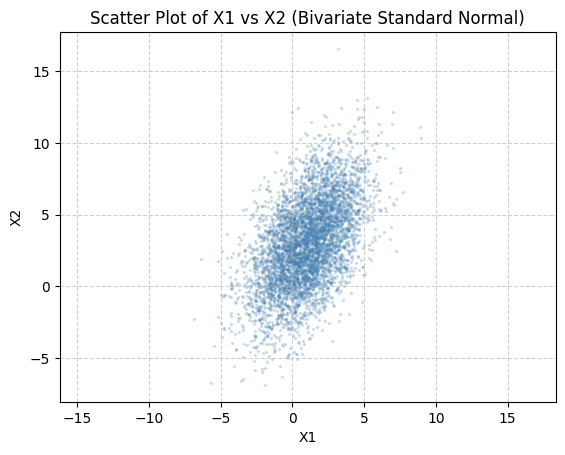

In [1]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.array([1, 3])
Sigma = np.array([[4, 3], [3, 9]])

# Step 1: Cholesky decomposition
L = np.linalg.cholesky(Sigma)

# Standard normal simulated using Box-Mullerfunction:
def simulate_normal_boxmuller(n):
    u1 = np.random.uniform(0, 1, n)
    u2 = np.random.uniform(0, 1, n)
    z1 = np.sqrt((-2) * np.log(u1)) * np.cos(2 * np.pi * u2)
    z2 = np.sqrt((-2) * np.log(u1)) * np.sin(2 * np.pi * u2)
    return z1, z2

# Step 2: simulate iid N(0,1)
n_mvn = 5000
z1, z2 = simulate_normal_boxmuller(n_mvn) # your code — shape (2, n)
Z = np.array([z1, z2])

# Additional step to prepare mu for sum up with L*Z
mu_col = mu.reshape(2, 1)

# Step 3: transform
X = mu_col + (L @ Z) # your code

################## PRINT X1 vs X2 to check results ################################
print("Shape of x_2d:", X.shape) # checking the shape of X for # X should have shape (2, n)
print ('X[1] with Variance = 4:', X[0])
print ('X[2] with Variance = 9:', X[1])
print(np.mean(X, axis=1))
print(np.cov(X))

################## PLOT X1 vs X2 to check correlation ro=0.5 ################################
plt.scatter(X[0], X[1], color='steelblue', s=2, alpha=0.2)

# Force the X and Y axes to have the exact same scale
# This is crucial! Without it, a perfect circle might look like an oval.
plt.axis('equal')

# Add context and labels
plt.title('Scatter Plot of X1 vs X2 (Bivariate Standard Normal)')
plt.xlabel('X1')
plt.ylabel('X2')

# Add a light grid for reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [13]:
#1.Necessary parameters for conditioning:
condition_val_X2 = 6
tolerance = 0.3

#2.Dividing X into X1 and X2 for NumPy masking:
X1 = X[0]
X2 = X[1]

#3.Masking:
mask = np.abs(X2 - condition_val_X2) < tolerance

#4.Conditioning:
X1_given_X2 = X1[mask]

#5.Control masking:
print(f"Original points: {len(X1)}")
print(f"Points where X2 ≈ 6: {len(X1_given_X2)}")

Original points: 5000
Points where X2 ≈ 6: 244


In [14]:
#6.Analytical conditioning:
conditional_mu1 = 2
conditional_sigma1 = 3
conditional_std = np.sqrt(conditional_sigma1)

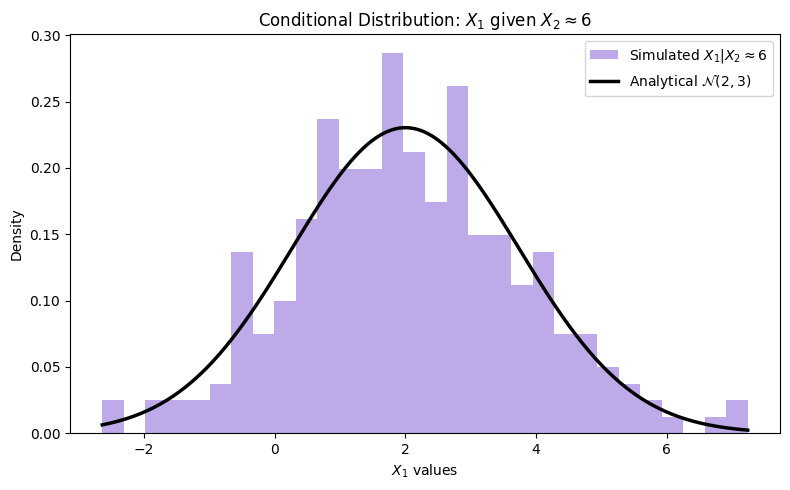

In [16]:
#7.Plotting:

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the simulated conditional histogram
ax.hist(X1_given_X2, bins=30, density=True, alpha=0.6, 
        color='mediumpurple', label=f'Simulated $X_1 | X_2 \\approx {condition_val_X2}$')

# Plot the theoretical PDF: N(2, 3)
x_vals = np.linspace(min(X1_given_X2), max(X1_given_X2), 300)
theoretical_pdf = (1 / (conditional_std * np.sqrt(2 * np.pi))) * \
                  np.exp(-0.5 * ((x_vals - conditional_mu1) / conditional_std)**2)

ax.plot(x_vals, theoretical_pdf, color='black', lw=2.5, 
        label=f'Analytical $\mathcal{{N}}({conditional_mu1}, {conditional_sigma1})$')

ax.set_xlabel('$X_1$ values')
ax.set_ylabel('Density')
ax.set_title(f'Conditional Distribution: $X_1$ given $X_2 \\approx {condition_val_X2}$')
ax.legend()
plt.tight_layout()
plt.show()

#3. Jacobian Transformation Numerically:

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Necessary parameters:
n = 100000
X = np.random.uniform(0, 1, n)
Y = np.random.uniform(0, 1, n)
U = X + Y
V = X - Y

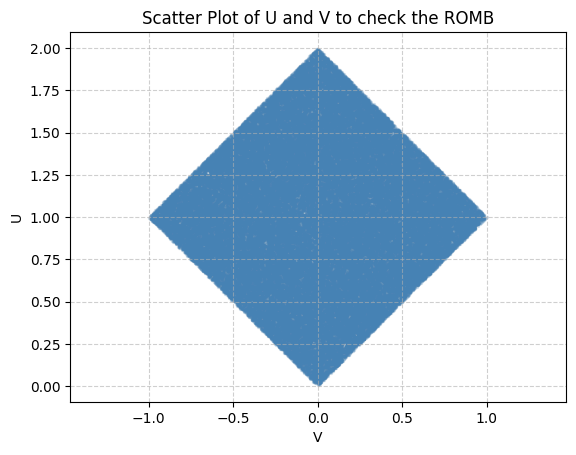

In [49]:
# (U,V) Scatterplot
plt.scatter(V, U, color='steelblue', s=2, alpha=0.2)
plt.axis('equal')

# Add context and labels
plt.title('Scatter Plot of U and V to check the ROMB')
plt.xlabel('V')
plt.ylabel('U')

# Add a light grid for reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

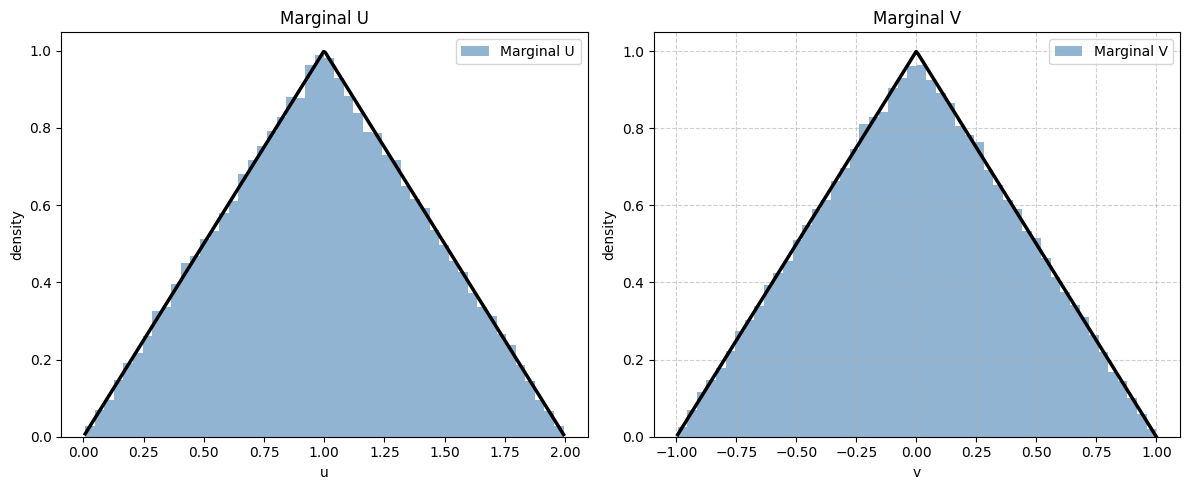

In [77]:
# Marginal U and V plots
# Universal preset for 2 - Plots:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Marginal U
axes[0].hist(U, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Marginal U')
axes[0].set_xlabel('u')
axes[0].set_ylabel('density')
axes[0].set_title(f'Marginal U')
axes[0].legend()

# U Theoretical pdf
u1 = np.linspace(min(U), max(U), 300) # Generate 300 evenly spaced U-values
theoretical_u = 1 - np.abs(u1-1)

# Plot theoretical f(u):
axes[0].plot(u1, theoretical_u, color='black', lw=2.5, 
        label=f'Analytical f(u)')

# Marginal V
axes[1].hist(V, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Marginal V')
axes[1].set_xlabel('v')
axes[1].set_ylabel('density')
axes[1].set_title(f'Marginal V')
axes[1].legend()

# V Theoretical pdf
v1 = np.linspace(min(V), max(V), 300) # Generate 300 evenly spaced U-values
theoretical_v = 1 - np.abs(v1)

# Plot theoretical f(v):
axes[1].plot(v1, theoretical_v, color='black', lw=2.5, 
        label=f'Analytical f(v)')

# Show:
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Confirming Jacobin |J| = 1/2 by: Var(U)+Var(V) vs 2(Var(X)+Var(Y))

In [38]:
print('Var(U) + Var(V) = ', np.var(U) + np.var(V))
print('2(Var(X) + Var(Y)) = ', 2*(np.var(X) + np.var(Y)))

Var(U) + Var(V) =  0.33424399215356465
2(Var(X) + Var(Y)) =  0.33424399215356465


#4. Verify Marginals from Joint

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Necessary parameters:
n = 50000
U1 = np.random.uniform(0, 1, n)
U2 = np.random.uniform(0, 1, n)
X = np.minimum(U1, U2)  # this is the smaller — plays role of x
Y = np.maximum(U1, U2)  # this is the larger — plays role of y

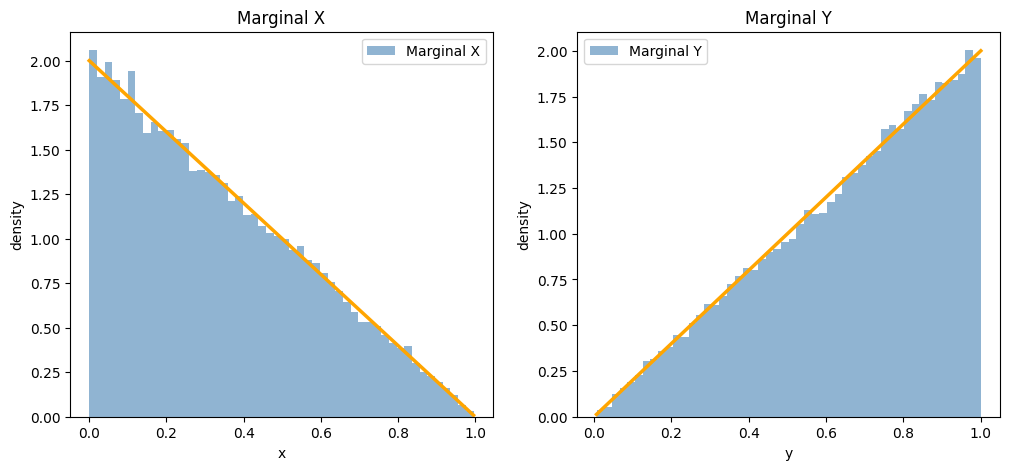

In [42]:
# Marginal X and Y plots
# Universal preset for 2 - Plots:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Theoretical marginal pdf of X:
x = np.linspace(min(X), max(X), 300)
theoretical_fx = 2 * (1-x)

# Marginal X
axes[0].hist(X, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Marginal X')
axes[0].set_xlabel('x')
axes[0].set_ylabel('density')
axes[0].set_title(f'Marginal X')
axes[0].legend()

# Theoretical f(x) pdf-Curve
axes[0].plot(x, theoretical_fx, 
        color='orange', lw=2.5, label=f'f(x) density')

###################################################################
# Theoretical marginal pdf of Y:
y = np.linspace(min(Y), max(Y), 300)
theoretical_fy = 2 * y

# Marginal Y
axes[1].hist(Y, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Marginal Y')
axes[1].set_xlabel('y')
axes[1].set_ylabel('density')
axes[1].set_title(f'Marginal Y')
axes[1].legend()

# Theoretical f(y) pdf-Curve
axes[1].plot(y, theoretical_fy, 
        color='orange', lw=2.5, label=f'f(y) density')

In [45]:
# Expectation of X and Y:
print('E[X] = ', np.mean(X), 'is equal to 1/3?', 1/3)
print('E[Y] = ', np.mean(Y), 'is equal to 2/3?', 2/3)

E[X] =  0.3322848206509105 is equal to 1/3? 0.3333333333333333
E[Y] =  0.667631035966815 is equal to 2/3? 0.6666666666666666


#5. Order statistics

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Necessary parameters:
n = 5
n_sims = 10000
# Simulate n_sims sets of n uniform samples, sort each
samples = np.random.uniform(0, 1, (n_sims, n))
order_stats = np.sort(samples, axis=1)
# order_stats[:, k-1] gives the k-th order statistic across all simulations

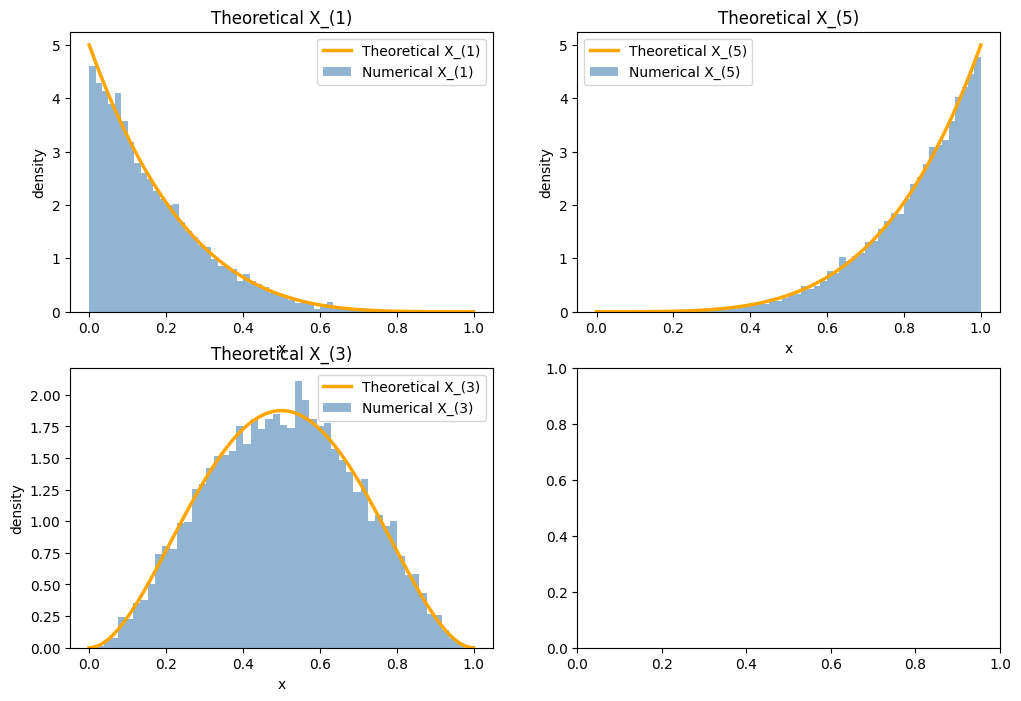

In [87]:
# Plot X_(1), X_(3), X_(5)
# Marginal X and Y plots
# Universal preset for 2 - Plots:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Theoretical X_(1) plot:
x = np.linspace(0, 1, 300)
theoretical_x1 = beta.pdf(x, 1, 5, loc=0, scale=1)
axes[0, 0].plot(x, theoretical_x1, 
        color='orange', lw=2.5, label=f'Theoretical X_(1)')

# Numerical X_(1) plot - Minimum
axes[0, 0].hist(order_stats[:,0], bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Numerical X_(1)')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('density')
axes[0, 0].set_title(f'Theoretical X_(1)')
axes[0, 0].legend()

# Theoretical X_(3) plot - Median:
theoretical_x3 = beta.pdf(x, 3, 3, loc=0, scale=1)
axes[1, 0].plot(x, theoretical_x3, 
        color='orange', lw=2.5, label=f'Theoretical X_(3)')

# Numerical X_(3) plot
axes[1, 0].hist(order_stats[:,2], bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Numerical X_(3)')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('density')
axes[1, 0].set_title(f'Theoretical X_(3)')
axes[1, 0].legend()

# Theoretical X_(5) plot - Maximum:
theoretical_x5 = beta.pdf(x, 5, 1, loc=0, scale=1)
axes[0, 1].plot(x, theoretical_x5, 
        color='orange', lw=2.5, label=f'Theoretical X_(5)')

# Numerical X_(5) plot
axes[0, 1].hist(order_stats[:,4], bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Numerical X_(5)')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('density')
axes[0, 1].set_title(f'Theoretical X_(5)')
axes[0, 1].legend()

In [81]:
# Expectations of X_(1), X_(3), X_(5)
print('E[X_(1)] = ', np.mean(order_stats[:,0]), 'vs k/(n+1) = 1/6 = ', 1/6)
print('E[X_(3)] = ', np.mean(order_stats[:,2]), 'vs k/(n+1) = 2/6 = ', 3/6)
print('E[X_(5)] = ', np.mean(order_stats[:,4]), 'vs k/(n+1) = 5/6 = ', 5/6)

E[X_(1)] =  0.1668742465157126 vs k/(n+1) = 1/6 =  0.16666666666666666
E[X_(3)] =  0.503585310578035 vs k/(n+1) = 2/6 =  0.3333333333333333
E[X_(5)] =  0.8338441736045396 vs k/(n+1) = 5/6 =  0.8333333333333334


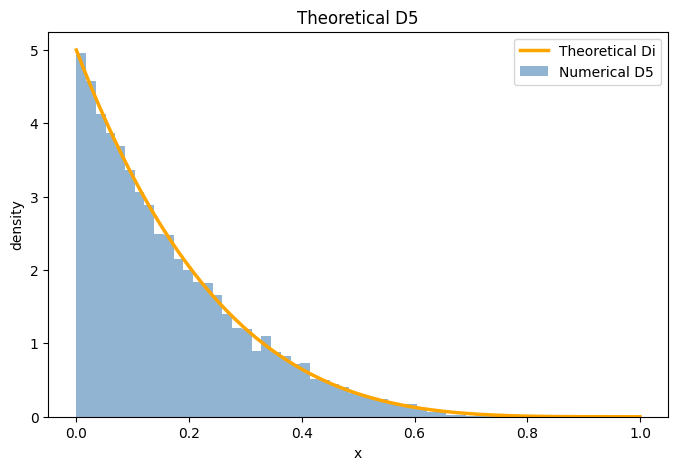

In [92]:
# Spacings numerically:
D1 = order_stats[:, 0]                       #X_(1)
D2 = order_stats[:, 1] - order_stats[:, 0]   #X_(2)
D3 = order_stats[:, 2] - order_stats[:, 1]   #X_(3)
D4 = order_stats[:, 3] - order_stats[:, 2]   #X_(4)
D5 = order_stats[:, 4] - order_stats[:, 3]   #X_(5)

# Spacings analytically: Each spacing follows identical ~Beta(1,n)
theoretical_Di = beta.pdf(x, 1, 5, loc=0, scale=1)

# Plotting Spacings:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, theoretical_Di, 
        color='orange', lw=2.5, label=f'Theoretical Di')

# Numerical X_(1) plot - Minimum
ax.hist(D5, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Numerical D5')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_title(f'Theoretical D5')
ax.legend()

#7. Exponential order stats

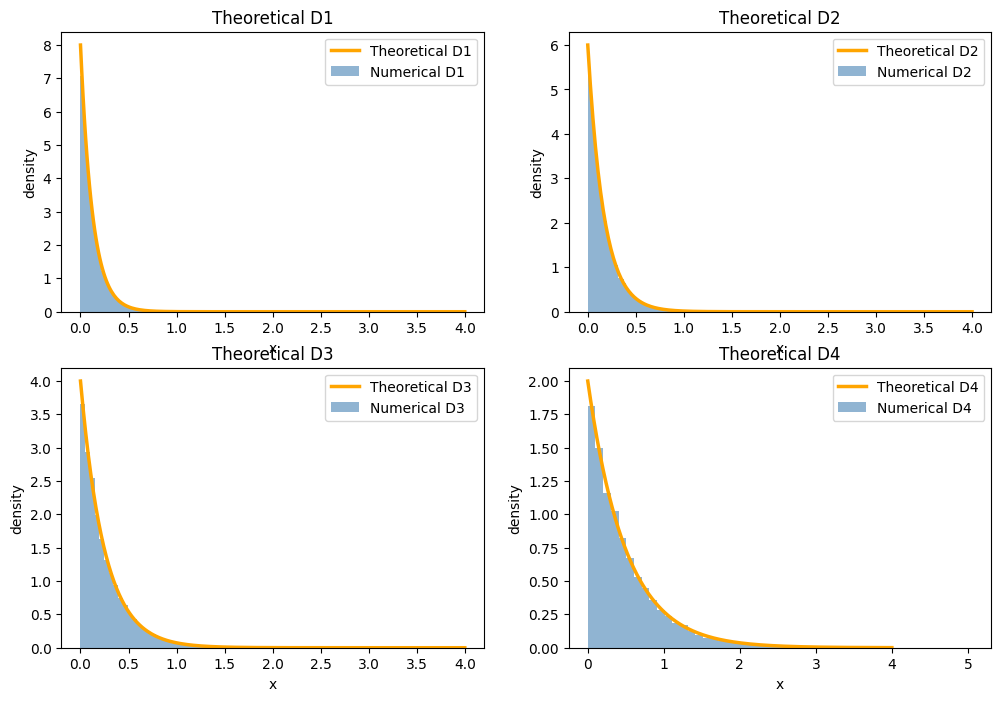

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Necessary parameters:
n = 4        # panels in the solar farm
lam = 2      # failure rate
n_sims = 20000

# Simulate n_sims sets of n exponential samples, sort each
samples = np.random.exponential(1/lam, (n_sims, n))
order_stats = np.sort(samples, axis=1)
# order_stats[:, k-1] gives the k-th order statistic across all simulations

# Spacings numerically:
D1 = order_stats[:, 0]                          # X_(1)
D2 = order_stats[:, 1] - order_stats[:, 0]      # X_(2) - X_(1)
D3 = order_stats[:, 2] - order_stats[:, 1]      # X_(3) - X_(2)
D4 = order_stats[:, 3] - order_stats[:, 2]      # X_(4) - X_(3)

# Spacings theoretically:
x_exp = np.linspace(0,4,300)
D1_th = 8 * np.exp((-8)*x_exp)
D2_th = 6 * np.exp((-6)*x_exp)
D3_th = 4 * np.exp((-4)*x_exp)
D4_th = 2 * np.exp((-2)*x_exp)

# Plotting Spacings:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#D1:
# Theoretical D1 plot
axes[0, 0].plot(x_exp, D1_th, 
        color='orange', lw=2.5, label=f'Theoretical D1')

# Numerical D1 plot
axes[0, 0].hist(D1, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Numerical D1')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('density')
axes[0, 0].set_title(f'Theoretical D1')
axes[0, 0].legend()

#D2:
# Theoretical D2 plot
axes[0, 1].plot(x_exp, D2_th, 
        color='orange', lw=2.5, label=f'Theoretical D2')

# Numerical D2 plot
axes[0, 1].hist(D2, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Numerical D2')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('density')
axes[0, 1].set_title(f'Theoretical D2')
axes[0, 1].legend()

#D3:
# Theoretical D3 plot
axes[1, 0].plot(x_exp, D3_th, 
        color='orange', lw=2.5, label=f'Theoretical D3')

# Numerical D3 plot
axes[1, 0].hist(D3, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Numerical D3')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('density')
axes[1, 0].set_title(f'Theoretical D3')
axes[1, 0].legend()

#D4:
# Theoretical D4 plot
axes[1, 1].plot(x_exp, D4_th, 
        color='orange', lw=2.5, label=f'Theoretical D4')

# Numerical D3 plot
axes[1, 1].hist(D4, bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Numerical D4')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('density')
axes[1, 1].set_title(f'Theoretical D4')
axes[1, 1].legend()

# Another function for order stats

In [100]:
# 1. Create columns of 0s and 1s that are the exact same height as your simulations
zeros_col = np.zeros(n_sims)
ones_col = np.ones(n_sims)

# 2. Stack them side-by-side: (0s, order_stats, 1s)
padded_stats = np.column_stack((zeros_col, order_stats, ones_col))

# 3. Calculate the spacings across the rows (axis=1)
spacings = np.diff(padded_stats, axis=1)

# Verify the shape
print(f"Shape of order_stats: {order_stats.shape}")
print(f"Shape of padded_stats: {padded_stats.shape}")
print(f"Shape of spacings: {spacings.shape}")

Shape of order_stats: (20000, 4)
Shape of padded_stats: (20000, 6)
Shape of spacings: (20000, 5)


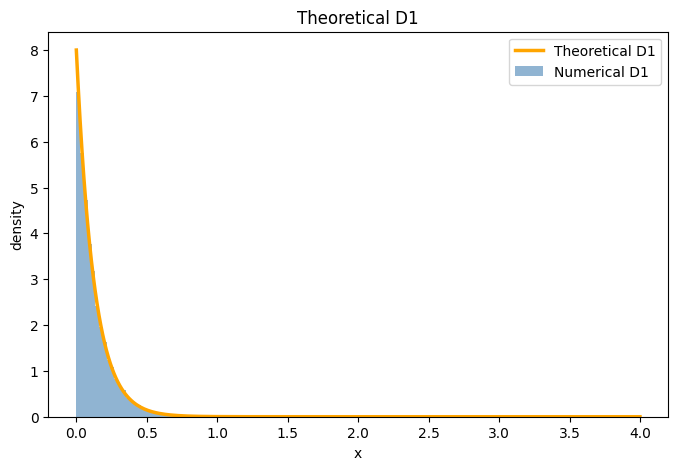

In [102]:
# Plotting Spacings:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x_exp, D1_th, 
        color='orange', lw=2.5, label=f'Theoretical D1')

ax.hist(spacings[:,0], bins=50, density=True, alpha=0.6, 
         color='steelblue', label=f'Numerical D1')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_title(f'Theoretical D1')
ax.legend()

In [105]:
print('E[D1] = ', np.mean(D1), 'Using np.diff():', np.mean(spacings[:,0]), 'theoretical 1/((n−k+1)λ', 1/8)
print('E[D2] = ', np.mean(D2), 'Using np.diff():', np.mean(spacings[:,1]), 'theoretical 1/((n−k+1)λ', 1/6)
print('E[D3] = ', np.mean(D3), 'Using np.diff():', np.mean(spacings[:,2]), 'theoretical 1/((n−k+1)λ', 1/4)
print('E[D4] = ', np.mean(D4), 'Using np.diff():', np.mean(spacings[:,3]), 'theoretical 1/((n−k+1)λ', 1/2)

E[D1] =  0.12571313446503124 Using np.diff(): 0.12571313446503124 theoretical 1/((n−k+1)λ 0.125
E[D2] =  0.1677794367052918 Using np.diff(): 0.1677794367052918 theoretical 1/((n−k+1)λ 0.16666666666666666
E[D3] =  0.2504513206858542 Using np.diff(): 0.2504513206858542 theoretical 1/((n−k+1)λ 0.25
E[D4] =  0.49760281909732673 Using np.diff(): 0.49760281909732673 theoretical 1/((n−k+1)λ 0.5


In [107]:
print('Sum of E[Di_s] = ', np.mean(D1) + np.mean(D2) + np.mean(D3) + np.mean(D4), 'vs. E[X_(4)] = ', np.mean(order_stats[:, 3]))

Sum of E[Di_s] =  1.041546710953504 vs. E[X_(4)] =  1.041546710953504
